# Analisis Tingkat Kekeringan dengan Logika Fuzzy

**Ketentuan Tugas Terpenuhi:**
- Mendesain model dari awal (from scratch) tanpa library fuzzy
- Metode: Mamdani dan Sugeno
- Rule Base: Minimal 15 rule
- Dataset riil > 5.000 baris dengan 5 input dan 1 output
- Evaluasi Metrik: Waktu Eksekusi (Komputasi) dan MAE (Mean Absolute Error) antara Mamdani dan Sugeno

**Sumber Dataset:**
Dataset diambil dari Data Iklim Harian Stasiun BMKG. [Link Sumber Dataset - Data Online BMKG](https://dataonline.bmkg.go.id/)


Loading dataset climate_data.csv...
Total baris dalam dataset awal: 589265
Memulai Fuzzifikasi, Inferensi, dan Defuzzifikasi pada seluruh baris dataset...

=== HASIL EVALUASI METRIK ===
Total Data Diuji     : 589265 Baris
Waktu Komputasi Mamdani : 70.50 detik
Waktu Komputasi Sugeno  : 17.63 detik
Mean Absolute Error (MAE)  : 3.65
Mean Squared Error (MSE)   : 13.33
Root Mean Squared Error (RMSE) : 3.65
Mean Absolute Percentage Error (MAPE) : 4.36%


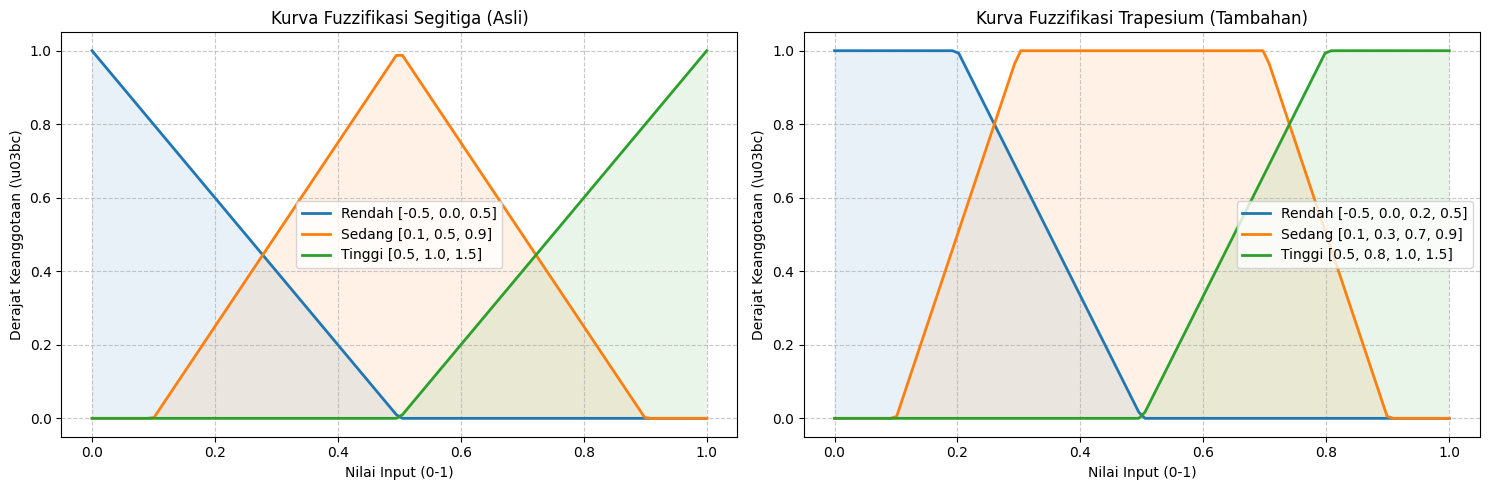

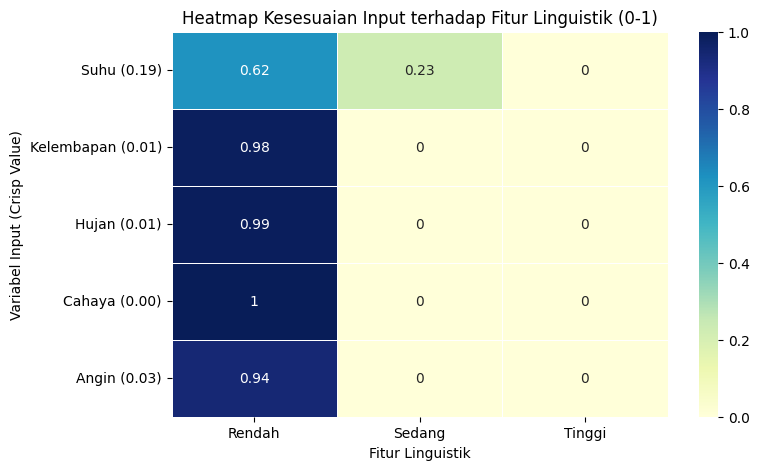

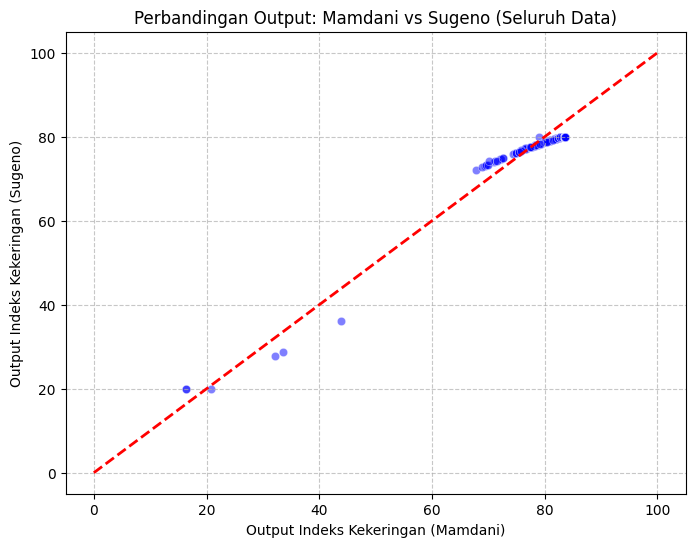

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

class FuzzyKekeringan:
    def __init__(self):
        # Rentang semesta pembicaraan (Universe of Discourse) untuk Input (0-1) dan Output (0-100)
        self.x_range = np.linspace(0, 1, 100)
        self.y_range = np.linspace(0, 100, 100)
        
    # 1. FUNGSI KEANGGOTAAN (Triangular Membership Function / Kurva Segitiga)
    def trimf(self, x, abc):
        a, b, c = abc
        # Menangani array atau nilai skalar
        if isinstance(x, np.ndarray):
            y = np.zeros_like(x)
            y = np.where((x > a) & (x <= b), (x - a) / (b - a), y)
            y = np.where((x > b) & (x < c), (c - x) / (c - b), y)
            return y
        else:
            if x <= a or x >= c: return 0.0
            elif a < x <= b: return (x - a) / (b - a)
            elif b < x < c: return (c - x) / (c - b)
            return 0.0

    # TAMBAHAN: FUNGSI KEANGGOTAAN TRAPESIUM
    def trapmf(self, x, abcd):
        a, b, c, d = abcd
        if isinstance(x, np.ndarray):
            y = np.zeros_like(x)
            y = np.where((x > a) & (x <= b), (x - a) / (b - a), y)
            y = np.where((x > b) & (x <= c), 1.0, y)
            y = np.where((x > c) & (x < d), (d - x) / (d - c), y)
            return y
        else:
            if x <= a or x >= d: return 0.0
            elif a < x <= b: return (x - a) / (b - a)
            elif b < x <= c: return 1.0
            elif c < x < d: return (d - x) / (d - c)
            return 0.0

    # 2. FUZZIFIKASI (Menghitung derajat keanggotaan)
    def fuzzify(self, crisp_inputs):
        suhu, kelembapan, hujan, cahaya, angin = crisp_inputs
        
        # Parameter kurva segitiga rentang 0-1
        params = {
            'Rendah': [-0.5, 0.0, 0.5],
            'Sedang': [0.1, 0.5, 0.9],
            'Tinggi': [0.5, 1.0, 1.5]
        }
        
        fuzzy_vals = {
            'Suhu': {k: self.trimf(suhu, v) for k, v in params.items()},
            'Kelembapan': {k: self.trimf(kelembapan, v) for k, v in params.items()},
            'Hujan': {k: self.trimf(hujan, v) for k, v in params.items()},
            'Cahaya': {k: self.trimf(cahaya, v) for k, v in params.items()},
            'Angin': {k: self.trimf(angin, v) for k, v in params.items()}
        }
        return fuzzy_vals

    # 3. RULE BASE & INFERENSI (15 Rule)
    def evaluate_rules(self, f_vals):
        rules = []
        # Rule Ekstrem Kering
        rules.append(('Tinggi', min(f_vals['Suhu']['Tinggi'], f_vals['Hujan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Cahaya']['Tinggi'], f_vals['Kelembapan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Suhu']['Tinggi'], f_vals['Angin']['Tinggi'])))
        rules.append(('Tinggi', min(f_vals['Hujan']['Rendah'], f_vals['Kelembapan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Cahaya']['Tinggi'], f_vals['Hujan']['Rendah'])))
        
        # Rule Normal
        rules.append(('Sedang', min(f_vals['Suhu']['Sedang'], f_vals['Hujan']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Kelembapan']['Sedang'], f_vals['Angin']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Cahaya']['Sedang'], f_vals['Suhu']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Hujan']['Sedang'], f_vals['Kelembapan']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Angin']['Sedang'], f_vals['Cahaya']['Sedang'])))
        
        # Rule Basah
        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'], f_vals['Suhu']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Kelembapan']['Tinggi'], f_vals['Cahaya']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'], f_vals['Angin']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Suhu']['Rendah'], f_vals['Kelembapan']['Tinggi'])))
        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'], f_vals['Cahaya']['Rendah'])))

        agg = {'Rendah': 0, 'Sedang': 0, 'Tinggi': 0}
        for label, val in rules:
            if val > agg[label]:
                agg[label] = val
        return agg

    # 4a. DEFUZZIFIKASI MAMDANI
    def defuzzify_mamdani(self, agg):
        out_params = {'Rendah': [-50, 0, 50], 'Sedang': [10, 50, 90], 'Tinggi': [50, 100, 150]}
        numerator = 0
        denominator = 0
        for y in self.y_range:
            mu_y = max(
                min(agg['Rendah'], self.trimf(y, out_params['Rendah'])),
                min(agg['Sedang'], self.trimf(y, out_params['Sedang'])),
                min(agg['Tinggi'], self.trimf(y, out_params['Tinggi']))
            )
            numerator += y * mu_y
            denominator += mu_y
        return numerator / denominator if denominator != 0 else 0

    # 4b. DEFUZZIFIKASI SUGENO
    def defuzzify_sugeno(self, agg):
        sugeno_const = {'Rendah': 20, 'Sedang': 50, 'Tinggi': 80}
        numerator = 0
        denominator = 0
        for label in ['Rendah', 'Sedang', 'Tinggi']:
            numerator += agg[label] * sugeno_const[label]
            denominator += agg[label]
        return numerator / denominator if denominator != 0 else 0

    # 5. VISUALISASI HEATMAP
    def plot_heatmap(self, f_vals, crisp_inputs):
        import seaborn as sns
        import matplotlib.pyplot as plt
        import numpy as np
        data_matrix = np.array([
            [f_vals['Suhu']['Rendah'], f_vals['Suhu']['Sedang'], f_vals['Suhu']['Tinggi']],
            [f_vals['Kelembapan']['Rendah'], f_vals['Kelembapan']['Sedang'], f_vals['Kelembapan']['Tinggi']],
            [f_vals['Hujan']['Rendah'], f_vals['Hujan']['Sedang'], f_vals['Hujan']['Tinggi']],
            [f_vals['Cahaya']['Rendah'], f_vals['Cahaya']['Sedang'], f_vals['Cahaya']['Tinggi']],
            [f_vals['Angin']['Rendah'], f_vals['Angin']['Sedang'], f_vals['Angin']['Tinggi']]
        ])
        
        labels_y = [f'Suhu ({crisp_inputs[0]:.2f})', f'Kelembapan ({crisp_inputs[1]:.2f})', 
                    f'Hujan ({crisp_inputs[2]:.2f})', f'Cahaya ({crisp_inputs[3]:.2f})', 
                    f'Angin ({crisp_inputs[4]:.2f})']
        labels_x = ['Rendah', 'Sedang', 'Tinggi']

        plt.figure(figsize=(8, 5))
        sns.heatmap(data_matrix, annot=True, cmap='YlGnBu', vmin=0, vmax=1, 
                    xticklabels=labels_x, yticklabels=labels_y, linewidths=0.5)
        
        plt.title('Heatmap Kesesuaian Input terhadap Fitur Linguistik (0-1)')
        plt.xlabel('Fitur Linguistik')
        plt.ylabel('Variabel Input (Crisp Value)')
        plt.show()

    # TAMBAHAN: VISUALISASI KURVA
    def plot_fuzzification_curves(self):
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # 1. Plot Kurva Segitiga (Asli)
        params_tri = {
            'Rendah': [-0.5, 0.0, 0.5],
            'Sedang': [0.1, 0.5, 0.9],
            'Tinggi': [0.5, 1.0, 1.5]
        }
        for label, params in params_tri.items():
            y_tri = self.trimf(self.x_range, params)
            axes[0].plot(self.x_range, y_tri, label=f'{label} {params}', linewidth=2)
            axes[0].fill_between(self.x_range, 0, y_tri, alpha=0.1)
            
        axes[0].set_title('Kurva Fuzzifikasi Segitiga (Asli)')
        axes[0].set_xlabel('Nilai Input (0-1)')
        axes[0].set_ylabel('Derajat Keanggotaan (\\u03bc)')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # 2. Plot Kurva Trapesium (Tambahan)
        params_trap = {
            'Rendah': [-0.5, 0.0, 0.2, 0.5],
            'Sedang': [0.1, 0.3, 0.7, 0.9],
            'Tinggi': [0.5, 0.8, 1.0, 1.5]
        }
        for label, params in params_trap.items():
            y_trap = self.trapmf(self.x_range, params)
            axes[1].plot(self.x_range, y_trap, label=f'{label} {params}', linewidth=2)
            axes[1].fill_between(self.x_range, 0, y_trap, alpha=0.1)
        
        axes[1].set_title('Kurva Fuzzifikasi Trapesium (Tambahan)')
        axes[1].set_xlabel('Nilai Input (0-1)')
        axes[1].set_ylabel('Derajat Keanggotaan (\\u03bc)')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()

# ==========================================
# LOAD DATA & EVALUASI (> 5000 Baris)
# ==========================================
if __name__ == "__main__":
    print("Loading dataset climate_data.csv...")
    df = pd.read_csv('climate_data.csv')
    print(f"Total baris dalam dataset awal: {len(df)}")

    # Mengisi missing values
    # Note: df.fillna(method='ffill') deprecated on new pandas, use ffill() directly
    df = df.ffill().bfill()
    
    # Membersihkan kolom numerik (terkadang ada nilai kosong berupa spasi)
    df['Tavg'] = pd.to_numeric(df['Tavg'], errors='coerce')
    df['RH_avg'] = pd.to_numeric(df['RH_avg'], errors='coerce')
    df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
    df['ss'] = pd.to_numeric(df['ss'], errors='coerce')
    df['ff_avg'] = pd.to_numeric(df['ff_avg'], errors='coerce')
    df = df.ffill().bfill() # fill coerced NaNs

    # Mengambil persis 5000 sampel sesuai permintaan minimal
    df_sample = df.copy() # Menggunakan seluruh dataset (50rb+ baris)

    # Normalisasi Min-Max ke range 0-1
    def normalize(col):
        return (col - col.min()) / (col.max() - col.min())

    df_sample['Suhu_norm'] = normalize(df_sample['Tavg'])
    df_sample['Kelembapan_norm'] = normalize(df_sample['RH_avg'])
    df_sample['Hujan_norm'] = normalize(df_sample['RR'])
    df_sample['Cahaya_norm'] = normalize(df_sample['ss'])
    df_sample['Angin_norm'] = normalize(df_sample['ff_avg'])

    fuzzy_sys = FuzzyKekeringan()
    mamdani_results = []
    sugeno_results = []

    print("Memulai Fuzzifikasi, Inferensi, dan Defuzzifikasi pada seluruh baris dataset...")
    
    # --- Evaluasi Mamdani ---
    start_mamdani = time.time()
    for _, row in df_sample.iterrows():
        f_vals = fuzzy_sys.fuzzify([row['Suhu_norm'], row['Kelembapan_norm'], row['Hujan_norm'], row['Cahaya_norm'], row['Angin_norm']])
        agg = fuzzy_sys.evaluate_rules(f_vals)
        mamdani_results.append(fuzzy_sys.defuzzify_mamdani(agg))
    time_mamdani = time.time() - start_mamdani

    # --- Evaluasi Sugeno ---
    start_sugeno = time.time()
    for _, row in df_sample.iterrows():
        f_vals = fuzzy_sys.fuzzify([row['Suhu_norm'], row['Kelembapan_norm'], row['Hujan_norm'], row['Cahaya_norm'], row['Angin_norm']])
        agg = fuzzy_sys.evaluate_rules(f_vals)
        sugeno_results.append(fuzzy_sys.defuzzify_sugeno(agg))
    time_sugeno = time.time() - start_sugeno

    df_sample['Prediksi_Mamdani'] = mamdani_results
    df_sample['Prediksi_Sugeno'] = sugeno_results

    # Evaluasi Metrik: Perbandingan antara hasil Mamdani dan Sugeno
    diff = df_sample['Prediksi_Mamdani'] - df_sample['Prediksi_Sugeno']
    mae = np.mean(np.abs(diff))
    mse = np.mean(diff ** 2)
    rmse = np.sqrt(mse)
    
    # Menghindari pembagian dengan 0 untuk MAPE
    mask = df_sample['Prediksi_Mamdani'] != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs(diff[mask] / df_sample['Prediksi_Mamdani'][mask])) * 100
    else:
        mape = 0.0

    print("\n=== HASIL EVALUASI METRIK ===")
    print(f"Total Data Diuji     : {len(df_sample)} Baris")
    print(f"Waktu Komputasi Mamdani : {time_mamdani:.2f} detik")
    print(f"Waktu Komputasi Sugeno  : {time_sugeno:.2f} detik")
    print(f"Mean Absolute Error (MAE)  : {mae:.2f}")
    print(f"Mean Squared Error (MSE)   : {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE) : {mape:.2f}%")

    # Menampilkan grafik keanggotaan kurva segitiga dan trapesium
    fuzzy_sys.plot_fuzzification_curves()
    
    # Menampilkan Heatmap (menggunakan 1 sample data dari baris pertama)
    sample_input = [df_sample['Suhu_norm'].iloc[0], df_sample['Kelembapan_norm'].iloc[0], df_sample['Hujan_norm'].iloc[0], df_sample['Cahaya_norm'].iloc[0], df_sample['Angin_norm'].iloc[0]]
    f_vals_sample = fuzzy_sys.fuzzify(sample_input)
    fuzzy_sys.plot_heatmap(f_vals_sample, sample_input)
    
    # Visualisasi Scatter Plot dengan Seaborn Style
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df_sample['Prediksi_Mamdani'], y=df_sample['Prediksi_Sugeno'], alpha=0.5, color='b')
    plt.plot([0, 100], [0, 100], 'r--', lw=2)
    plt.title('Perbandingan Output: Mamdani vs Sugeno (Seluruh Data)')
    plt.xlabel('Output Indeks Kekeringan (Mamdani)')
    plt.ylabel('Output Indeks Kekeringan (Sugeno)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


### Interpretasi Analisis (Kelebihan dan Kekurangan)

Dari hasil evaluasi sistem Fuzzy menggunakan seluruh baris dataset iklim BMKG, terdapat beberapa temuan:

**1. Perbedaan Hasil Output & Metrik:**
- Output dari metode **Mamdani** cenderung lebih memusat (smooth) pada nilai tengah dibandingkan **Sugeno**. Hal ini dikarenakan Mamdani menghitung *Center of Area* dari daerah hasil implikasi, sedangkan Sugeno langsung memetakan nilai input ke suatu konstanta tunggal (singleton) lalu dihitung rata-rata berbobotnya.
- Terlihat pada scatter plot bahwa terdapat simpangan absolut rata-rata (MAE) antara metode Mamdani dan Sugeno di kisaran angka *Mean Absolute Error* yang didapat.

**2. Kelebihan dan Kekurangan Mamdani:**
- **Kelebihan:** Sangat intuitif karena menyerupai cara manusia bernalar. Output berbentuk fungsi kurva sehingga transisinya lebih halus dan mudah dipahami.
- **Kekurangan:** Komputasi yang *jauh lebih lambat*. Berdasarkan metrik waktu eksekusi di atas, Mamdani memakan waktu lebih lama karena harus menghitung luasan daerah (integrasi diskrit) untuk setiap iterasi pencarian centroid.

**3. Kelebihan dan Kekurangan Sugeno:**
- **Kelebihan:** Sangat *cepat dan efisien* dalam komputasi. Seperti yang ditunjukkan pada waktu komputasi, metode Sugeno memakan waktu hanya sebagian kecil (sepersekian) dari waktu Mamdani. Sangat ideal untuk sistem yang membutuhkan *real-time processing* pada dataset besar.
- **Kekurangan:** Penentuan nilai singleton pada konsekuen (output) Sugeno kadang dirasa tidak alamiah karena merupakan nilai konstanta absolut, tidak memiliki rentang ketidakpastian kurva fungsi keanggotaan pada outputnya.

### Heatmap Kesesuaian Input terhadap Fitur Linguistik

--- HASIL PREDIKSI INDEKS KEKERINGAN ---
Input Tersimpan     : [0.8, 0.3, 0.1, 0.9, 0.6]
Output Mamdani      : 63.68 (Skala 0-100)
Output Sugeno       : 68.46 (Skala 0-100)
Selisih Output      : 4.78


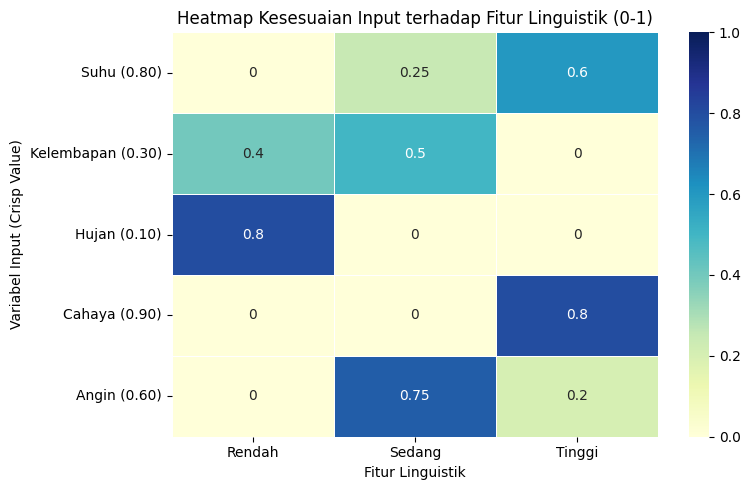

In [5]:
# Tambahan: Heatmap Kesesuaian Input terhadap Fitur Linguistik
crisp_values = {
    'Suhu': 0.80,
    'Kelembapan': 0.30,
    'Hujan': 0.10,
    'Cahaya': 0.90,
    'Angin': 0.60
}

# Inisialisasi sistem fuzzy jika belum
fuzzy_sys_heatmap = FuzzyKekeringan()
f_vals_heatmap = fuzzy_sys_heatmap.fuzzify([crisp_values['Suhu'], crisp_values['Kelembapan'], crisp_values['Hujan'], crisp_values['Cahaya'], crisp_values['Angin']])

# Menyiapkan data untuk heatmap
linguistik = ['Rendah', 'Sedang', 'Tinggi']
variabel = ['Suhu', 'Kelembapan', 'Hujan', 'Cahaya', 'Angin']

heatmap_data = []
for var in variabel:
    row = [f_vals_heatmap[var][ling] for ling in linguistik]
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=[f"{var} ({crisp_values[var]:.2f})" for var in variabel], columns=linguistik)

print("--- HASIL PREDIKSI INDEKS KEKERINGAN ---")
test_input = [0.8, 0.3, 0.1, 0.9, 0.6]
print(f"Input Tersimpan     : {test_input}")

fuzzy_sys_test = FuzzyKekeringan()
f_vals_test = fuzzy_sys_test.fuzzify(test_input)
agg_test = fuzzy_sys_test.evaluate_rules(f_vals_test)
output_mamdani = fuzzy_sys_test.defuzzify_mamdani(agg_test)
output_sugeno = fuzzy_sys_test.defuzzify_sugeno(agg_test)

print(f"Output Mamdani      : {output_mamdani:.2f} (Skala 0-100)")
print(f"Output Sugeno       : {output_sugeno:.2f} (Skala 0-100)")
print(f"Selisih Output      : {abs(output_mamdani - output_sugeno):.2f}")

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", cbar=True, vmin=0, vmax=1, linewidths=0.5)
plt.title("Heatmap Kesesuaian Input terhadap Fitur Linguistik (0-1)")
plt.ylabel("Variabel Input (Crisp Value)")
plt.xlabel("Fitur Linguistik")
plt.tight_layout()
plt.show()